In [1]:
import os
import numpy as np
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow import data as tf_data
import matplotlib.pyplot as plt

In [79]:
image_size = (128, 128)
batch_size = 32

train_ds, val_ds = keras.utils.image_dataset_from_directory(
    "../images",
    validation_split=0.2,
    subset="both",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
)
class_names = train_ds.class_names

Found 101000 files belonging to 101 classes.
Using 80800 files for training.
Using 20200 files for validation.


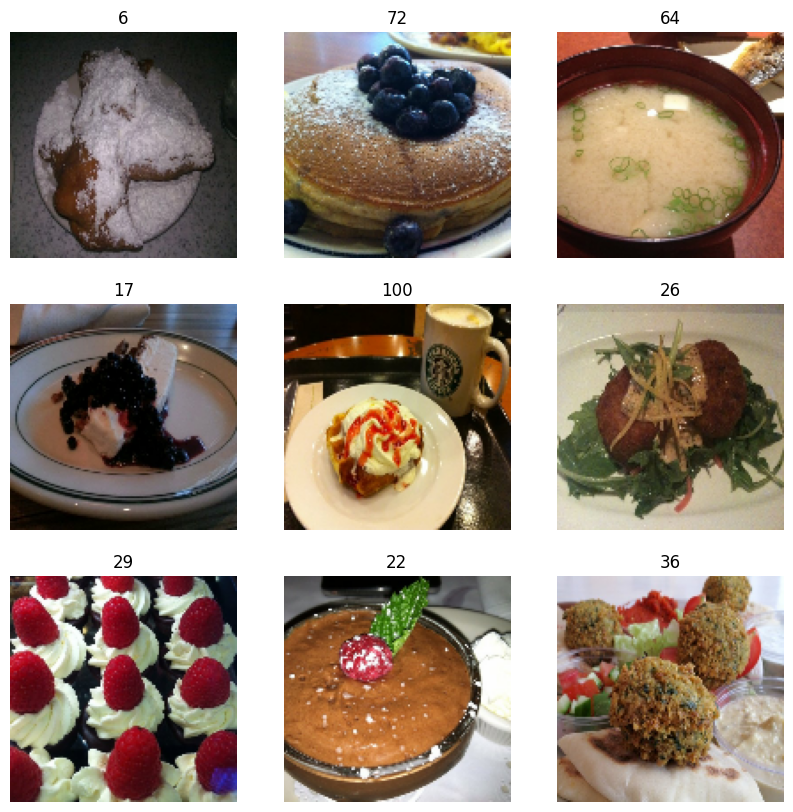

In [3]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(np.array(images[i]).astype("uint8"))
        plt.title(int(labels[i]))
        plt.axis("off")

In [4]:
data_augmentation_layers = [
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
]


def data_augmentation(images):
    for layer in data_augmentation_layers:
        images = layer(images)
    return images

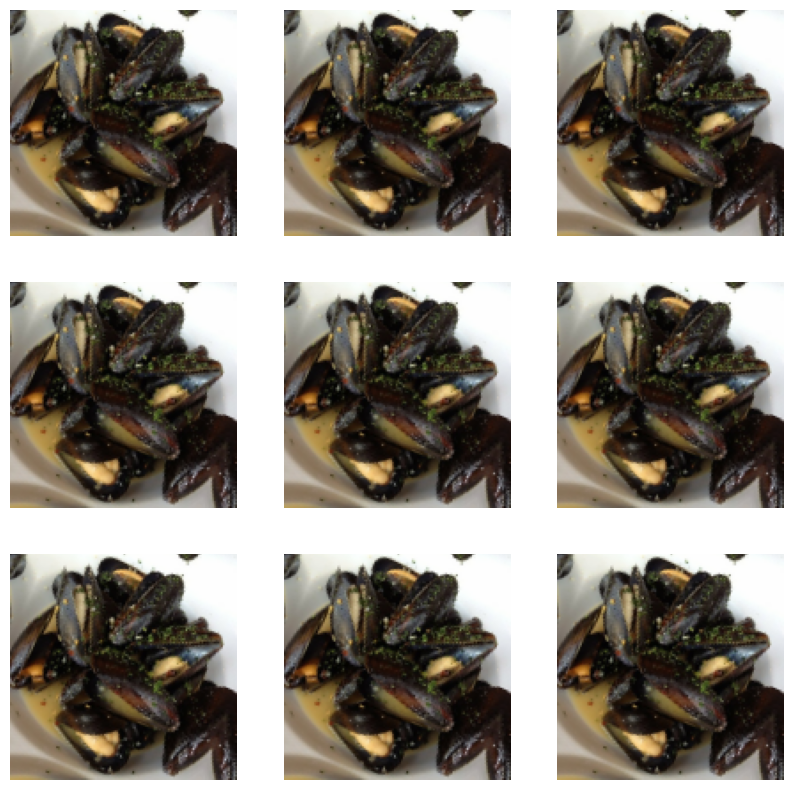

In [5]:
plt.figure(figsize=(10, 10))
for images, _ in train_ds.take(1):
    augmented_images = data_augmentation(images)
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(np.array(augmented_images[0]).astype("uint8"))
        plt.axis("off")

In [6]:
train_ds = train_ds.map(
    lambda img, label: (data_augmentation(img), label),
    num_parallel_calls=tf_data.AUTOTUNE,
)
# Prefetching samples in GPU memory helps maximize GPU utilization.
train_ds = train_ds.prefetch(tf_data.AUTOTUNE)
val_ds = val_ds.prefetch(tf_data.AUTOTUNE)

# --- OLD MODEL ---
def make_model(input_shape, num_classes):
    inputs = keras.Input(shape=input_shape)
    x = data_augmentation(inputs)
    x = layers.Rescaling(1./255)(x)
    # Entry block
    x = layers.Rescaling(1.0 / 255)(inputs)
    x = layers.Conv2D(128, 3, strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    previous_block_activation = x  # Set aside residual

    for size in [256, 512, 728]:
        x = layers.Activation("relu")(x)
        x = layers.SeparableConv2D(size, 3, padding="same")(x)
        x = layers.BatchNormalization()(x)

        x = layers.Activation("relu")(x)
        x = layers.SeparableConv2D(size, 3, padding="same")(x)
        x = layers.BatchNormalization()(x)

        x = layers.MaxPooling2D(3, strides=2, padding="same")(x)

        # Project residual
        residual = layers.Conv2D(size, 1, strides=2, padding="same")(
            previous_block_activation
        )
        x = layers.add([x, residual])  # Add back residual
        previous_block_activation = x  # Set aside next residual

    x = layers.SeparableConv2D(1024, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    x = layers.GlobalAveragePooling2D()(x)
    if num_classes == 2:
        units = 1
    else:
        units = num_classes

    x = layers.Dropout(0.25)(x)
    # We specify activation=None so as to return logits
    outputs = layers.Dense(units, activation=None)(x)
    return keras.Model(inputs, outputs)


model = make_model(input_shape=image_size + (3,), num_classes=101)
keras.utils.plot_model(model, show_shapes=True)


In [12]:
base_model = keras.applications.EfficientNetV2S(
    include_top=False,
    weights="imagenet",
    input_shape=image_size + (3,)
)
base_model.trainable = False

def make_model(input_shape, num_classes):
    inputs = keras.Input(shape=input_shape)
    x = keras.applications.efficientnet_v2.preprocess_input(inputs)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.25)(x)
    outputs = layers.Dense(num_classes)(x)
    return keras.Model(inputs, outputs)

model = make_model(input_shape=image_size + (3,), num_classes=len(class_names))

In [14]:
epochs = 10
callbacks = [
    keras.callbacks.ModelCheckpoint("rough_tune_at_{epoch}.keras"),
    keras.callbacks.EarlyStopping(
        monitor="val_acc",
        patience=5,        # Stop if no improvement for 5 epochs
        restore_best_weights=True
    ),
]

model.compile(
    optimizer=keras.optimizers.Adam(3e-4),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=[keras.metrics.SparseCategoricalAccuracy(name="acc")]
    )

history = model.fit(
    train_ds,
    epochs=epochs,
    callbacks=callbacks,
    validation_data=val_ds,
)

Epoch 1/10
2525/2525 [==============================] - 183s 66ms/step - loss: 2.9155 - acc: 0.3425 - val_loss: 2.1941 - val_acc: 0.4672
Epoch 2/10
2525/2525 [==============================] - 159s 63ms/step - loss: 2.2361 - acc: 0.4557 - val_loss: 1.9842 - val_acc: 0.5063
Epoch 3/10
2525/2525 [==============================] - 160s 63ms/step - loss: 2.0804 - acc: 0.4866 - val_loss: 1.8956 - val_acc: 0.5246
Epoch 4/10
2525/2525 [==============================] - 160s 63ms/step - loss: 2.0022 - acc: 0.5032 - val_loss: 1.8463 - val_acc: 0.5353
Epoch 5/10
2525/2525 [==============================] - 160s 63ms/step - loss: 1.9501 - acc: 0.5130 - val_loss: 1.8153 - val_acc: 0.5423
Epoch 6/10
2525/2525 [==============================] - 182s 72ms/step - loss: 1.9106 - acc: 0.5203 - val_loss: 1.7909 - val_acc: 0.5482
Epoch 7/10
2525/2525 [==============================] - 169s 67ms/step - loss: 1.8865 - acc: 0.5252 - val_loss: 1.7715 - val_acc: 0.5534
Epoch 8/10
2525/2525 [===================

In [15]:
epochs = 20
callbacks = [
    keras.callbacks.ModelCheckpoint("fine_tune_at_{epoch}.keras"),
    keras.callbacks.EarlyStopping(
        monitor="val_acc",
        patience=15,        # Stop if no improvement for 5 epochs
        restore_best_weights=True
    ),
]
base_model.trainable = True

model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=[keras.metrics.SparseCategoricalAccuracy(name="acc")],
)

history_fine = model.fit(
    train_ds, 
    epochs=epochs,
    callbacks=callbacks,
    validation_data=val_ds, 
)

Epoch 1/20
2525/2525 [==============================] - 373s 140ms/step - loss: 1.4311 - acc: 0.6289 - val_loss: 1.3319 - val_acc: 0.6523
Epoch 2/20
2525/2525 [==============================] - 352s 139ms/step - loss: 1.1754 - acc: 0.6889 - val_loss: 1.2392 - val_acc: 0.6765
Epoch 3/20
2525/2525 [==============================] - 370s 146ms/step - loss: 1.0246 - acc: 0.7247 - val_loss: 1.2013 - val_acc: 0.6857
Epoch 4/20
2525/2525 [==============================] - 352s 139ms/step - loss: 0.9045 - acc: 0.7531 - val_loss: 1.1692 - val_acc: 0.6966
Epoch 5/20
2525/2525 [==============================] - 370s 146ms/step - loss: 0.7934 - acc: 0.7819 - val_loss: 1.1797 - val_acc: 0.6975
Epoch 6/20
2525/2525 [==============================] - 372s 147ms/step - loss: 0.6994 - acc: 0.8061 - val_loss: 1.1971 - val_acc: 0.6999
Epoch 7/20
2525/2525 [==============================] - 370s 146ms/step - loss: 0.6065 - acc: 0.8281 - val_loss: 1.1915 - val_acc: 0.7061
Epoch 8/20
2525/2525 [============

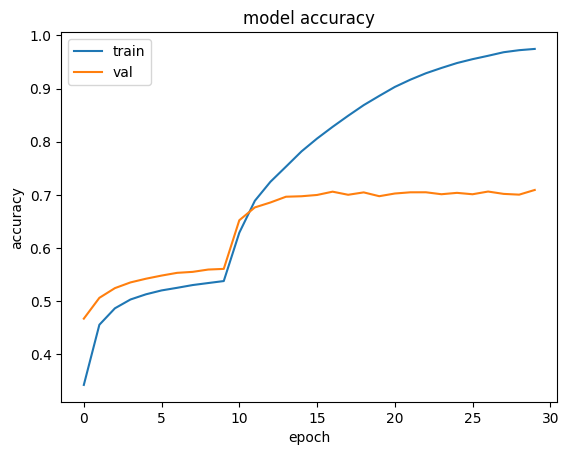

In [19]:
from matplotlib import pyplot as plt

plt.plot(history.history['acc'] + history_fine.history['acc'])
plt.plot(history.history['val_acc'] + history_fine.history['val_acc'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

# --- REGULAR TRAINING ---
epochs = 20
quit()
callbacks = [
    keras.callbacks.ModelCheckpoint("save_at_{epoch}.keras"),
]
model.compile(
    optimizer=keras.optimizers.Adam(3e-4),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=[keras.metrics.SparseCategoricalAccuracy(name="acc")],
)
history = model.fit(
    train_ds,
    epochs=epochs,
    callbacks=callbacks,
    validation_data=val_ds,
)

# --- THIS AS WELL ---
plt.plot(history.history['acc'])
plt.plot(history.history['val_acc'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [2]:
from tensorflow import keras
# Reload the model with highest validation accuracy
model = keras.models.load_model("fine_tune_at_20.keras")

In [51]:
classifications = {
    "Soup": ["chocolate_mousse", "clam_chowder", "creme_brulee", "french_onion_soup", "frozen_yogurt", "hot_and_sour_soup", "ice_cream", "lobster_bisque", "miso_soup", "pho", "ramen"],
    "Salad": ["apple_pie", "beef_carpaccio",  "beef_tartare", "beet_salad", "bibimbap", "bread_pudding", "bruschetta", "caesar_salad", "caprese_salad", "ceviche", "cheese_plate", "chicken_curry", "chicken_wings", "crab_cakes", "deviled_eggs", "edamame", "eggs_benedict", "escargots", "falafel", "french_fries", "fried_calamari", "fried_rice", "gnocchi", "greek_salad", "guacamole", "huevos_rancheros", "hummus", "lasagna", "macaroni_and_cheese", "mussels", "nachos", "onion_rings", "oysters", "pad_thai", "paella", "panna_cotta", "peking_duck", "poutine", "ravioli", "risotto", "scallops", "seaweed_salad", "shrimp_and_grits", "spaghetti_bolognese", "spaghetti_carbonara", "takoyaki", "tuna_tartare"],
    "Sandwich":["baby_back_ribs", "baklava", "beignets", "breakfast_burrito", "cannoli", "carrot_cake", "cheesecake", "chicken_quesadilla", "chocolate_cake", "churros", "club_sandwich", "croque_madame", "cup_cakes", "donuts", "dumplings", "filet_mignon", "fish_and_chips", "foie_gras", "french_toast", "garlic_bread", "grilled_cheese_sandwich", "grilled_salmon", "gyoza", "hamburger", "hot_dog", "lobster_roll_sandwich", "macarons", "omelette", "pancakes", "pizza", "pork_chop", "prime_rib", "pulled_pork_sandwich", "red_velvet_cake", "samosa", "sashimi", "spring_rolls", "steak", "strawberry_shortcake", "sushi", "tacos", "tiramisu", "waffles"]
}

beef_tartare
1/1 [==============================] - 0s 34ms/step
Soup: 0.00%
Salad: 95.44%
Sandwich: 4.56%

Subcategories:
apple_pie: 95.39%
carrot_cake: 4.33%
baklava: 0.23%
bread_pudding: 0.03%
lasagna: 0.02%


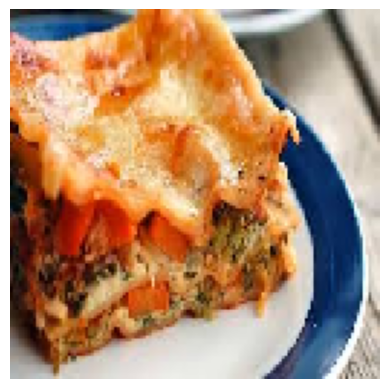

In [77]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import os
import random
import math

folder = random.choice(os.listdir("../images"))

print(folder)
# Load image
img = keras.utils.load_img(
    "../images/"+folder+"/"+random.choice(os.listdir("../images/"+folder)),
    target_size=image_size
)

img = keras.utils.load_img(
    "../../Downloads/images.jpg",
    target_size=image_size
)

plt.imshow(img)
plt.axis("off")

# Convert to array
img_array = keras.utils.img_to_array(img)

# Add batch dimension
img_array = np.expand_dims(img_array, axis=0)

# Predict
predictions = model.predict(img_array)

# Convert logits to probabilities
probabilities = tf.nn.softmax(predictions[0])

class_predictions = {"Soup":0, "Salad":0, "Sandwich":0}
for i in range(len(probabilities)):
    found = False
    for key, classes in classifications.items():

        if class_names[i] in classes:
            found = True
            class_predictions[key] += np.array(probabilities)[i]
    if not found:
        print(class_names[i])

for key, value in class_predictions.items():
    print(f"{key}: {value*100:.2f}%")
# Get top class
predicted_class = np.argmax(probabilities)
confidence = float(np.max(probabilities))

top_5 = np.argsort(probabilities)[-5:][::-1]
print("\nSubcategories:")
for i in top_5:
    print(f"{train_ds.class_names[i]}: {probabilities[i]*100:.2f}%")

#print(f"Predicted class: {class_names[predicted_class]}")
#print(f"Confidence: {confidence * 100:.2f}%")